In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [70]:
import sys
sys.path.append("/home/geraldine/Documents/Research/Projects/BayesGPT/")
print(sys.path)

['/snap/pycharm-professional/590/plugins/python-ce/helpers/jupyter_debug', '/snap/pycharm-professional/590/plugins/python-ce/helpers/pydev', '/home/geraldine/Documents/Research/Projects/BayesGPT', '/home/geraldine/Documents/Research/Projects/BayesGPT/bayesgpt', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/geraldine/Documents/Research/Projects/BayesGPT/.venv/lib/python3.12/site-packages', '/home/geraldine/Documents/Research/Projects/BayesGPT/', '/home/geraldine/Documents/Research/Projects/BayesGPT/', '/home/geraldine/Documents/Research/Projects/BayesGPT/', '/home/geraldine/Documents/Research/Projects/BayesGPT/']


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import bayesflow as bf

In [72]:
from bayesgpt.simulators.model_family import NestedModelFamily

In [73]:
from bayesgpt.simulators import NestedModelFamily
from bayesgpt.simulators.benchmarks import DDM
from bayesgpt.simulators.benchmarks.ddms.ddm_priors import ddm_priors, ddm_priors1, ddm_priors2
from bayesgpt.simulators.benchmarks.ddms.ddm_link_fun import ddm_link_fun
from bayesgpt.utils.simulator_utils import inspect

In [74]:
model_family = NestedModelFamily(
    model=DDM(),
    prior_fun=ddm_priors2(),
    mask_randomizer_kwargs=dict(
        free_intrinsics=["v", "a", "tau"],
        fixed_intrinsics=["s_v", "s_tau"],
        fixed_values={"s_v": 0, "s_tau": 0}
    )
)

In [75]:
samples = model_family.batch_sample(
    batch_size=10,
    max_num_regressors=2,
    max_num_categories=2,
    keep_intercept=True,
    add_interaction=True
)

In [76]:
samples["design_configs"]

[{'1': ['v', 'a', 'tau', 's_tau'],
  'u_1': ['a', 'tau'],
  'u_2': ['v', 'a', 'tau', 's_tau'],
  'u_1:u_2': ['a', 'tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['s_v', 's_tau'],
  'u_2': ['tau', 's_v', 's_tau'],
  'u_1:u_2': ['s_v', 's_tau']},
 {'1': ['v', 'a', 'tau', 's_v'], 'u_1': ['a'], 'u_2': ['s_v']},
 {'1': ['v', 'a', 'tau']},
 {'1': ['v', 'a', 'tau', 's_tau'], 'u_1': ['v', 'a', 'tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['v', 'a', 's_v', 's_tau']},
 {'1': ['v', 'a', 'tau'], 'u_1': ['a'], 'u_2': ['v']},
 {'1': ['v', 'a', 'tau'], 'u_1': ['v', 'a'], 'u_2': ['a'], 'u_1:u_2': ['a']},
 {'1': ['v', 'a', 'tau'],
  'u_1': ['v', 'a', 'tau'],
  'u_2': ['v', 'tau'],
  'u_1:u_2': ['v', 'tau']},
 {'1': ['v', 'a', 'tau'], 'u_1': ['a', 'tau'], 'u_2': ['a'], 'u_1:u_2': ['a']}]

In [77]:
samples["param_matrices"]

array([[-0.05216518,  0.07582831, -1.14012451,  0.        , -1.54213158,
         0.        ,  0.74030176,  0.52170428,  0.        ,  0.        ,
        -0.18098947, -0.48639478, -0.35474709,  0.        , -0.47218144,
         0.        ,  1.28659582, -0.59105256,  0.        ,  0.        ],
       [-0.00912928, -0.53488311, -0.78595348, -1.35487715, -0.83795153,
         0.        ,  0.        ,  0.        , -0.90675514,  0.39130242,
         0.        ,  0.        ,  1.73357785,  0.10026671,  1.31988139,
         0.        ,  0.        ,  0.        , -0.19344447,  0.21691774],
       [ 0.92899793,  0.15737222, -0.40979362, -0.8922994 ,  0.        ,
         0.        ,  1.16054506,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.92329484,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 1.01475319,  0.81304143, -0.96722816,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  

In [78]:
class DDMModelFamilyBF(bf.simulators.Simulator):

    def __init__(self):
        self.model_family = NestedModelFamily(
            model=DDM(),
            prior_fun=ddm_priors(),
            mask_randomizer_kwargs=dict(
                free_intrinsics=["v", "a", "tau", "s_v", "s_tau"],
                fixed_intrinsics=[],
                fixed_values={}
            ),
    )

    def sample(self, batch_size, num_obs=500, flatten_param_outputs=True, check=False, **kwargs):
        intrinsic_params = ["v", "a", "tau", "s_v", "s_tau"]

        design_config = {
            "1": intrinsic_params,
            "u_1": ["v", "a", "tau", "s_v"],
            "u_2": ["v", "a", "tau"],
            "u_1:u_2": ["v", "a"]
        }

        if isinstance(batch_size, tuple):
             batch_size = batch_size[0]

        sample_kwargs = {
            "design_config": design_config,
            "max_num_regressors": 2,
            "max_num_categories": 2,
        }

        samples = self.model_family.batch_sample(
            batch_size=batch_size,
            num_obs=num_obs,
            flatten_param_outputs=flatten_param_outputs,
            link_fun=ddm_link_fun(),
            **sample_kwargs,
            **kwargs
        )

        rts = samples["sim_data"]["rts"]
        choices = samples["sim_data"]["choices"]
        params = samples["param_matrices"]

        # Special treatment for BF:
        # Trim away zeros from non-regressed params
        # params = params[:, params[0] != 0]
        out = {"rts": rts, "choices": choices, "params": params}

        if check:
            f = self.model_family.check_regressed_priors(
                design_config=design_config,
                num_obs=num_obs,
                link_fun=ddm_link_fun(),
                run_simulator=True
            )
            inspect(samples)
            g, ax = plt.subplots(1, 1, figsize=(18, 5))
            for i in range(batch_size):
                ax = sns.histplot(out["rts"][i], bins=50, kde=True, legend=False)
                print(out['params'][i])

        return out

In [79]:
ddm_family_simulator = DDMModelFamilyBF()
ddm_samples = ddm_family_simulator.sample(1, check=True)

TypeError: 'rv_continuous_frozen' object is not subscriptable

In [17]:
# Define adapter
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(["rts", "choices"], into="summary_variables")
    .rename("params", "inference_variables")
)

In [33]:
# define networks
summary_net = bf.networks.SetTransformer(
    summary_dim=256,
    seed_dim=128,
    num_seeds=40,
    dropout=0.05,
    layer_norm=True
)
inference_net = bf.networks.FlowMatching()

In [35]:
# define checkpoint filepath
checkpoint_path ="../checkpoints/ddm_families_bf_interaction"

In [36]:
workflow = bf.BasicWorkflow(
    simulator=ddm_family_simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    checkpoint_filepath=checkpoint_path
)

In [39]:
history = workflow.fit_online(
    epochs=100,
    steps_per_epoch=50,
    batch_size=32
)

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_families_bf_interaction/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


In [40]:
val_data = workflow.simulate(500)

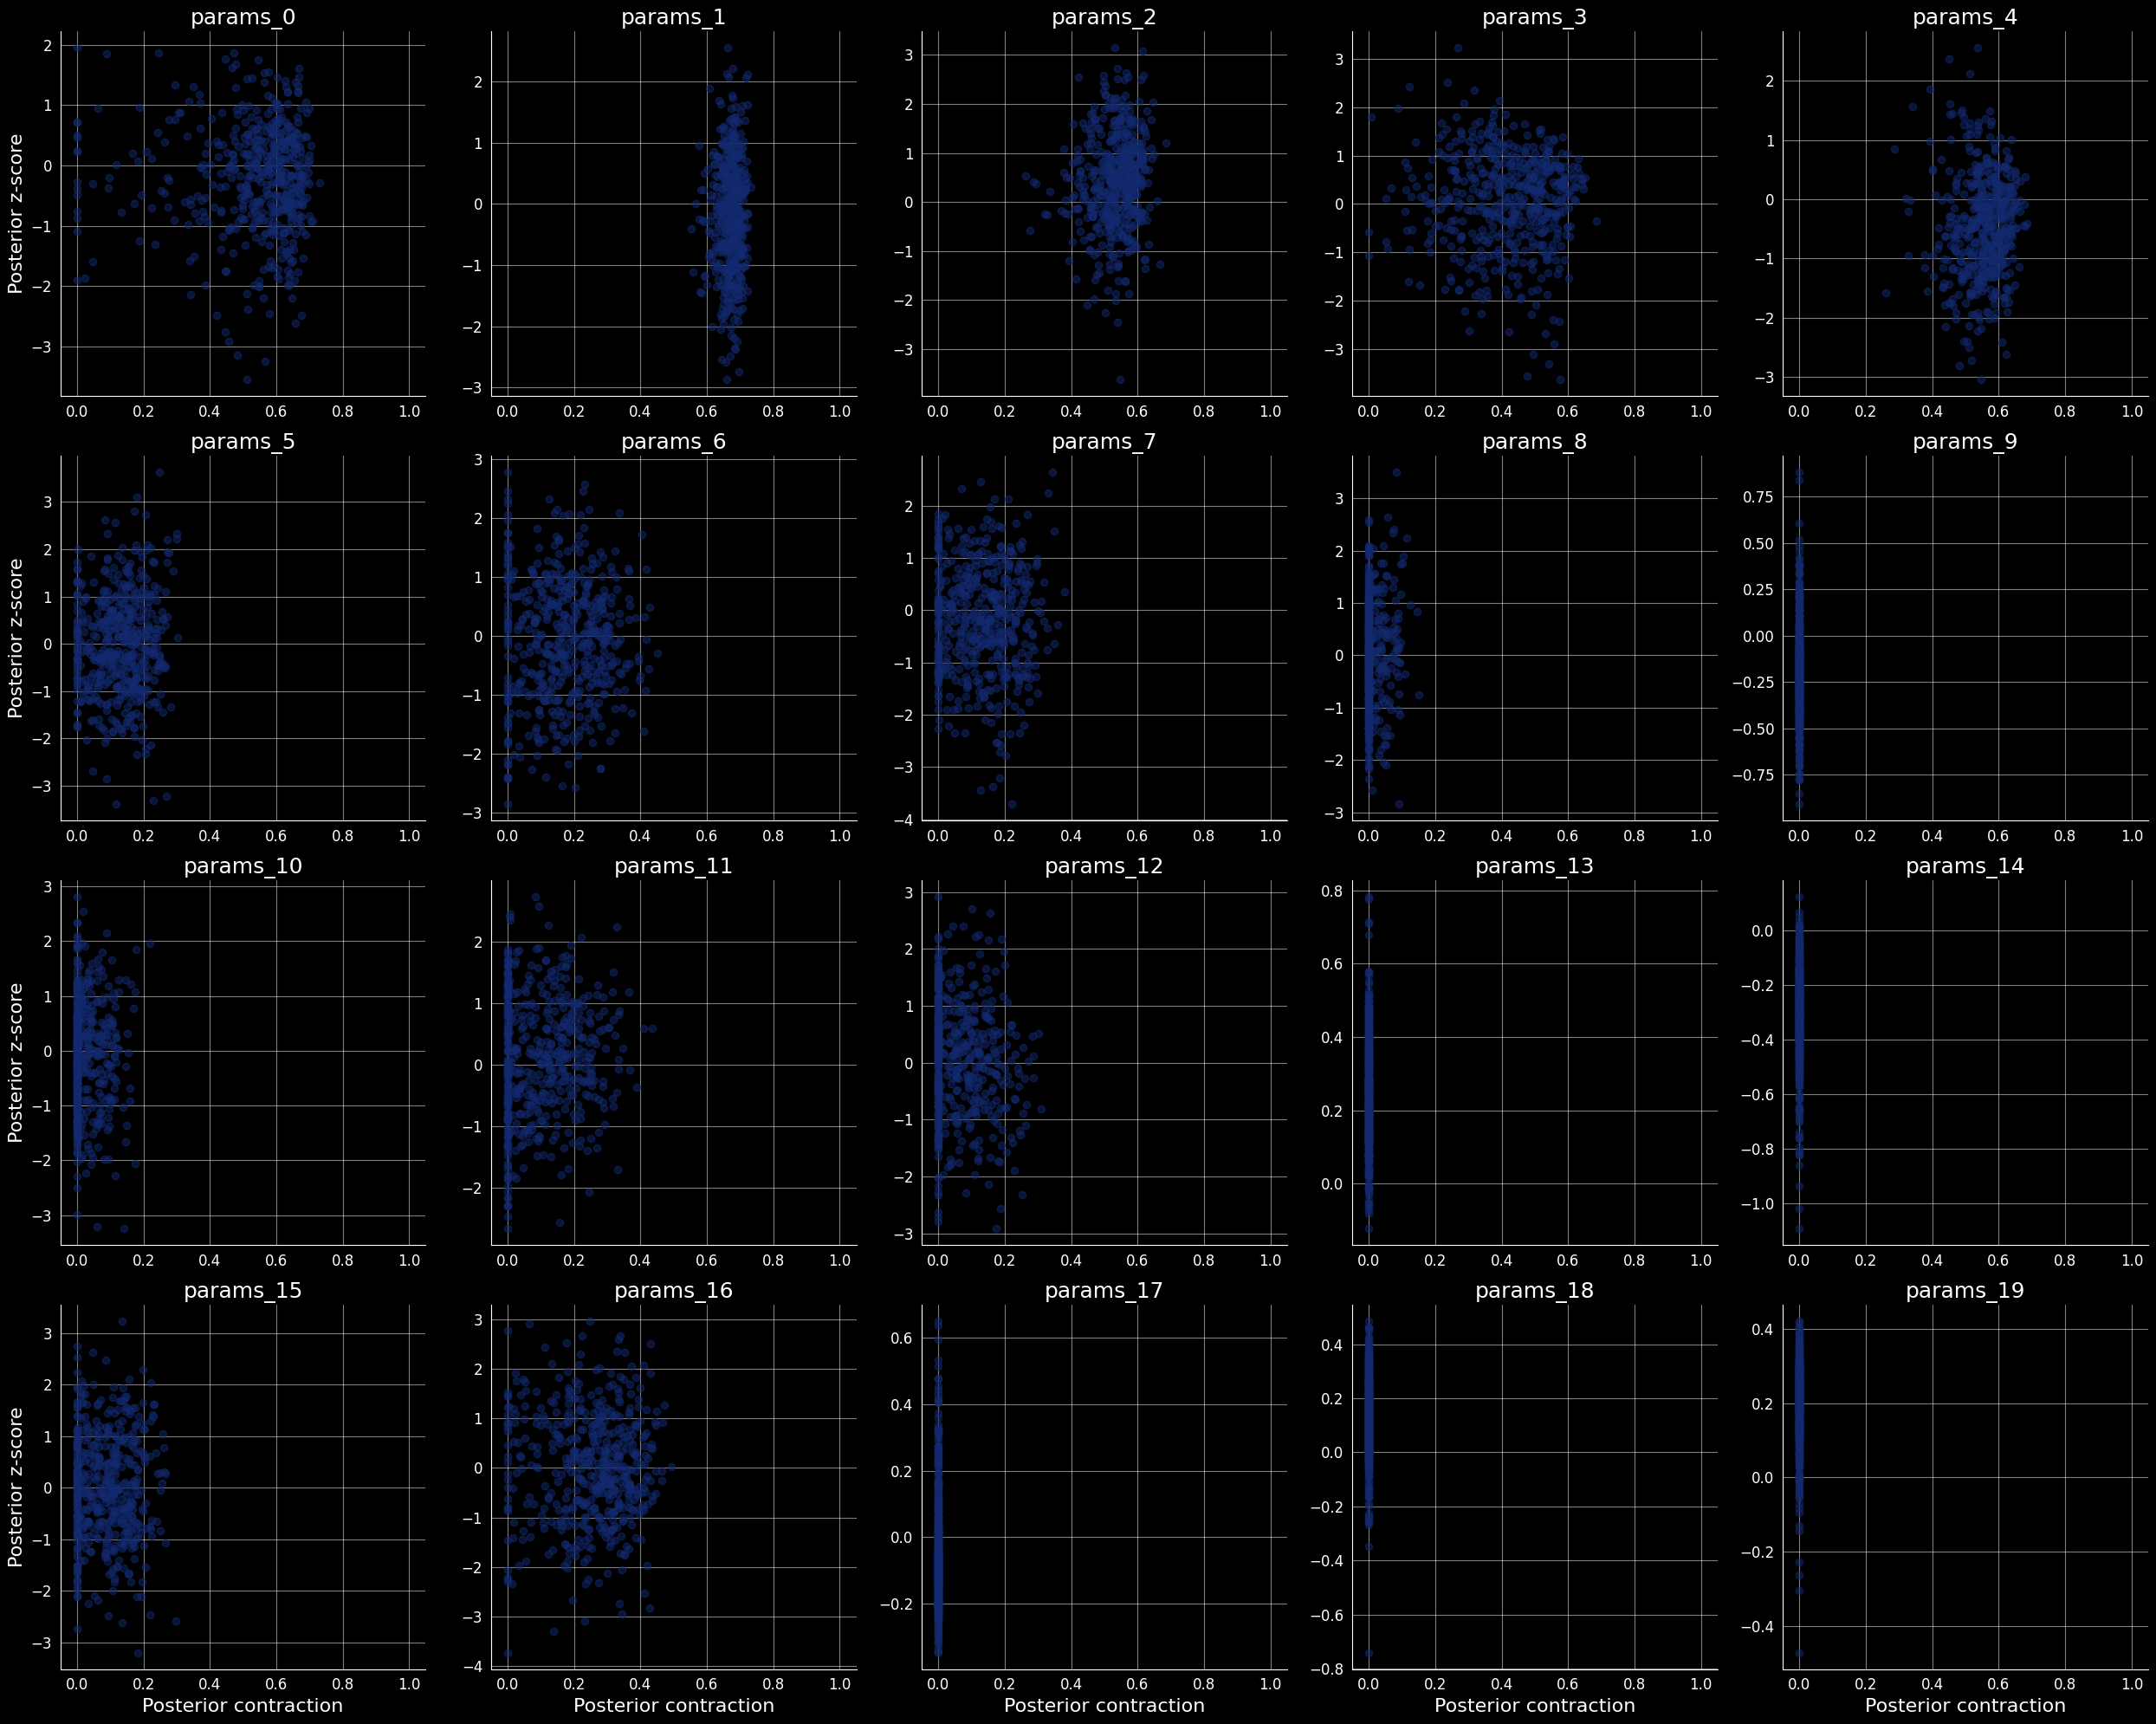

In [42]:
fig = workflow.plot_default_diagnostics(
    test_data=val_data,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": (15, 12), "label_fontsize": 12},
)